<!-- # Aerial animations

Short driver for Eriswil flare aerial frames and all-flare statistics. Heavy logic lives in `utilities.aerials_util`; no publication/PSD YAML required. -->

In [2]:
import sys
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    display = print

REPO_ROOT = Path.cwd().resolve()
for parent in (REPO_ROOT, *REPO_ROOT.parents):
    if (parent / "src" / "utilities" / "aerials_util.py").is_file():
        REPO_ROOT = parent
        break

for path in (REPO_ROOT, REPO_ROOT / "src"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from utilities.aerials_util import (
    AerialsPlotConfig,
    AerialsRunConfig,
    build_plan_view_products,
    load_aerials_dataset,
    prepare_aerials_context,
    render_facette_overview,
    render_plan_view_animation,
    write_all_flare_statistics,
)


In [3]:

# FLARE_IDX_LIST = [0, 1, 4, 5, 8, 9]
# REF_IDX_LIST = [0, 0, 1, 1, 2, 2
run_configs = {}
plot_configs = {}

In [4]:
# # ensemble config 400m
# run_configs["400m"] = AerialsRunConfig(
#     cs_run="cs-eriswil__20260328_205320",
#     cs_runs_dir=None,  # or Path("/work/.../cosmo-specs-runs")
#     domain_xy="50x42",
#     flare_idx_list=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11),
#     ref_idx_list=(0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2,),
#     time_debug_stride=24,
#     altitude_slice=(80, None),
#     seed_start="2023-01-25T12:29:50",
#     plot_window=("2023-01-25T12:29:50", "2023-01-25T13:05:00"),
#     plot_all_frames=True,
#     render_video=True,
#     rechunk_on_load=True,  # Slurm/debug: skip slow post-concat rechunk
#     dask_open_time_chunk=16,  # Split source NetCDF reads; previous single chunks were ~4.6 GB.
#     dask_profile=True,  # Levante profiling: writes HTML/JSON/CSV under output/gfx/png/.../dask_profile
#     )
# plot_configs["400m"] = AerialsPlotConfig(
#     lat_lon_frames_parallel=False,
#     lat_lon_profile_frames=True,
#     dask_profile=run_configs["400m"].dask_profile,
#     dask_profile_dir=run_configs["400m"].dask_profile_dir,
#     dask_profile_memory_interval=run_configs["400m"].dask_profile_memory_interval,
# )


In [5]:
# ensemble config 100m
run_configs["100m"] = AerialsRunConfig(
    cs_run="cs-eriswil__20260428_094815",
    cs_runs_dir=None,  # or Path("/work/.../cosmo-specs-runs")
    domain_xy="200x160",
    flare_idx_list=(0, 1, 2),
    ref_idx_list=(0, 0, 0,),
    time_debug_stride=6,
    altitude_slice=(80, None),
    seed_start="2023-01-25T12:29:50",
    plot_window=("2023-01-25T12:29:50", "2023-01-25T13:05:00"),
    plot_all_frames=False,
    render_video=False,
    rechunk_on_load=True,  # Slurm/debug: skip slow post-concat rechunk
    dask_open_time_chunk=8,  # Split source NetCDF reads; previous single chunks were ~4.6 GB.
    dask_profile=False,  # Levante profiling: writes HTML/JSON/CSV under output/gfx/png/.../dask_profile
)
plot_configs["100m"] = AerialsPlotConfig(
    lat_lon_frames_parallel=False,
    lat_lon_profile_frames=False,
    dask_profile=run_configs["100m"].dask_profile,
    dask_profile_dir=run_configs["100m"].dask_profile_dir,
    dask_profile_memory_interval=run_configs["100m"].dask_profile_memory_interval,
)

In [ ]:
# load data and render products
for (rkey, rval), (pkey, pval) in zip(run_configs.items(), plot_configs.items()):
    ctx = prepare_aerials_context(rval)
    display(ctx.diff_table)

    data = load_aerials_dataset(ctx, rval)
    products = build_plan_view_products(
        ctx,
        data.ds_3d,
        pval,
        compute_plan_arrays=rval.plot_all_frames or rval.render_video,
    )

    facette_paths = render_facette_overview(
        ctx,
        data.ds_3d,
        products,
        time_window=rval.plot_window,
        col_wrap=3,
        max_panels=9,
    )

    # movie = render_plan_view_animation(
    #     ctx,
    #     products,
    #     plot_all_frames=rval.plot_all_frames,
    #     render_video=rval.render_video,
    # )

    stats = write_all_flare_statistics(
        ctx,
        data.stats_3d,
        products.cfg,
        dask_profile=rval.dask_profile,
        dask_profile_dir=rval.dask_profile_dir,
        dask_profile_memory_interval=rval.dask_profile_memory_interval,
    )

    display(stats)
    print(f"facette_paths, movie: {facette_paths}")


cs_run: cs-eriswil__20260428_094815 domain: 200x160
model_data_path: /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_200x160x100/ensemble_output/cs-eriswil__20260428_094815
extpar_file: /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/extPar_Eriswil_200x160.nc
plot window: 2023-01-25T12:29:50 2023-01-25T13:05:00
Ensemble config differences (COSMO-SPECS / INPUT_ORG)
experiments in diff (4): 20260428094825, 20260428094828, 20260428094831, 20260428094822


,flare_run,reference_run,sbm_par.ishape,domain,flare_sbm.flare_emission,flare_sbm.lflare_inp,sbm_par.lflare,sbm_par.outputname
0,20260428094825,20260428094822,4,'200x160xZ',1000000.0,True,True,'3D_20260428094825'
1,20260428094828,20260428094822,4,'200x160xZ',3000000.0,True,True,'3D_20260428094828'
2,20260428094831,20260428094822,4,'200x160xZ',10000000.0,True,True,'3D_20260428094831'


#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -p compute
#SBATCH -A bb1376
#SBATCH -n 1
#SBATCH --cpus-per-task=4
#SBATCH --mem=103G
#SBATCH -t 02:00:00
#SBATCH --output=./logs/%j.out
#SBATCH --error=./logs/%j.err
#SBATCH --propagate=STACK
source ~/.bashrc
conda activate pcpaper_env
export OMP_NUM_THREADS=1
export MKL_NUM_THREADS=1
export OPENBLAS_NUM_THREADS=1
export VECLIB_MAXIMUM_THREADS=1
export NUMEXPR_NUM_THREADS=1
ulimit -s unlimited
ulimit -c 0
/home/b/b382237/.conda/envs/pcpaper_env/bin/python -m distributed.cli.dask_worker tcp://136.172.124.7:41091 --name dummy-name --nthreads 1 --memory-limit 25.61GiB --nworkers 4 --nanny --death-timeout 60

Waiting for 4 Dask workers (timeout=10m)...
Dask resource summary:
  - Jobs/nodes: 1
  - Worker processes/job: 4
  - Threads/process: 1
  - Memory/worker: 27.50 GB
  - Local directory: Dask default
Scheduler workers: 4/4
Remote dashboard address: http://136.172.124.7:8787
Setup ssh port forwarding: ssh -L 8787:136.172.124.7:8787 le

In [ ]:

facette_paths = render_facette_overview(
    ctx,
    data.ds_3d,
    products,
    time_window=rval.plot_window,
    col_wrap=3,
    max_panels=9,
)

# movie = render_plan_view_animation(
#     ctx,
#     products,
#     plot_all_frames=rval.plot_all_frames,
#     render_video=rval.render_video,
# )

stats = write_all_flare_statistics(
    ctx,
    data.stats_3d,
    products.cfg,
    dask_profile=rval.dask_profile,
    dask_profile_dir=rval.dask_profile_dir,
    dask_profile_memory_interval=rval.dask_profile_memory_interval,
)

display(stats)
print(f"facette_paths, movie: {facette_paths}")

file:///home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/png/aerials/cs-eriswil__20260428_094815/facette_cs-eriswil__20260428_094815_200x160_20260428094825_area.png
file:///home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/png/aerials/cs-eriswil__20260428_094815/facette_cs-eriswil__20260428_094815_200x160_20260428094828_area.png
file:///home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/png/aerials/cs-eriswil__20260428_094815/facette_cs-eriswil__20260428_094815_200x160_20260428094831_area.png
loaded all-flare statistics from file:///home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/png/aerials/cs-eriswil__20260428_094815/intermediate_statistics/all_flare_statistics_200x160_cs-eriswil_20260428_094815.nc


<xarray.Dataset> Size: 79kB
Dimensions:                         (expname: 3, time: 229)
Coordinates:
  * expname                         (expname) <U14 168B '20260428094825' ... ...
  * time                            (time) datetime64[ns] 2kB 2023-01-25T12:2...
    ref_expname                     (expname) <U14 168B '20260428094822' ... ...
Data variables: (12/14)
    icnc_prod_domain_sum            (expname, time) float64 5kB -1.306e+03 .....
    cdnc_reduction_3x3_sum          (expname, time) float64 5kB nan ... 883.3
    supersat_water_flare_pct        (expname, time) float64 5kB -7.475 ... -8...
    supersat_water_ref_pct          (expname, time) float64 5kB -7.475 ... -8...
    supersat_water_delta_pct        (expname, time) float64 5kB -2.035e-05 .....
    supersat_ice_flare_pct          (expname, time) float64 5kB -3.337 ... -4...
    ...                              ...
    ice_mass_produced_kg            (expname, time) float64 5kB 0.0 ... 1.6
    ice_mass_evaporating_kg         (expname, time) float64 5kB -0.0 0.0 ... 0.0
    ice_mass_lowest_level_kg        (expname, time) float64 5kB 0.0 0.0 ... 0.0
    cum_ice_mass_produced_kg        (expname, time) float64 5kB 0.0 ... 8.12e+04
    cum_ice_mass_evaporating_kg     (expname, time) float64 5kB -0.0 ... 7.85...
    cum_ice_mass_lowest_level_kg_s  (expname, time) float64 5kB 0.0 0.0 ... 0.0
Attributes:
    description:       All flare-candidate bulk, ice-budget, and supersaturat...
    var_lims:          [1.e+00 1.e+08]
    units:             L-1
    cs_run:            cs-eriswil__20260428_094815
    domain_xy:         200x160
    flare_candidates:  20260428094825,20260428094828,20260428094831

facette_paths, movie: [PosixPath('/home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/png/aerials/cs-eriswil__20260428_094815/facette_cs-eriswil__20260428_094815_200x160_20260428094825_area.png'), PosixPath('/home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/png/aerials/cs-eriswil__20260428_094815/facette_cs-eriswil__20260428_094815_200x160_20260428094828_area.png'), PosixPath('/home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/png/aerials/cs-eriswil__20260428_094815/facette_cs-eriswil__20260428_094815_200x160_20260428094831_area.png')]


In [ ]:
import xarray as xr

stats_400m_path = REPO_ROOT / Path("./data/processed/cs-eriswil__20260328_205320/lv2_statistics_3d/all_flare_statistics_50x42_cs-eriswil_20260328_205320.nc")
stats_100m_path = REPO_ROOT / Path("./data/processed/cs-eriswil__20260428_094815/lv2_statistics_3d/all_flare_statistics_200x160_cs-eriswil_20260428_094815.nc")

stats_400m = xr.open_dataset(stats_400m_path)
stats_100m = xr.open_dataset(stats_100m_path)

In [ ]:

display(stats_400m)

<xarray.Dataset> Size: 30kB
Dimensions:                         (expname: 12, time: 20, track_var: 2)
Coordinates:
  * expname                         (expname) <U14 672B '20260328205322' ... ...
  * time                            (time) datetime64[ns] 160B 2023-01-25T12:...
  * track_var                       (track_var) <U2 16B 'ni' 'ns'
    ref_expname                     (expname) <U14 672B ...
Data variables: (12/14)
    icnc_prod_domain_sum            (expname, time) float64 2kB ...
    cdnc_reduction_3x3_sum          (expname, track_var, time) float64 4kB ...
    supersat_water_flare_pct        (expname, time) float64 2kB ...
    supersat_water_ref_pct          (expname, time) float64 2kB ...
    supersat_water_delta_pct        (expname, time) float64 2kB ...
    supersat_ice_flare_pct          (expname, time) float64 2kB ...
    ...                              ...
    ice_mass_produced_kg            (expname, time) float64 2kB ...
    ice_mass_evaporating_kg         (expname, time) float64 2kB ...
    ice_mass_lowest_level_kg        (expname, time) float64 2kB ...
    cum_ice_mass_produced_kg        (expname, time) float64 2kB ...
    cum_ice_mass_evaporating_kg     (expname, time) float64 2kB ...
    cum_ice_mass_lowest_level_kg_s  (expname, time) float64 2kB ...
Attributes:
    description:         All flare-candidate bulk, ice-budget, and supersatur...
    var_lims:            [1.e+00 1.e+08]
    units:               L-1
    n_tobac_track_rows:  286
    cs_run:              cs-eriswil__20260328_205320
    domain_xy:           50x42
    flare_candidates:    20260328205322,20260328205324,20260328205326,2026032...

In [ ]:
display(stats_100m)

<xarray.Dataset> Size: 79kB
Dimensions:                         (expname: 3, time: 229)
Coordinates:
  * expname                         (expname) <U14 168B '20260428094825' ... ...
  * time                            (time) datetime64[ns] 2kB 2023-01-25T12:2...
    ref_expname                     (expname) <U14 168B ...
Data variables: (12/14)
    icnc_prod_domain_sum            (expname, time) float64 5kB ...
    cdnc_reduction_3x3_sum          (expname, time) float64 5kB ...
    supersat_water_flare_pct        (expname, time) float64 5kB ...
    supersat_water_ref_pct          (expname, time) float64 5kB ...
    supersat_water_delta_pct        (expname, time) float64 5kB ...
    supersat_ice_flare_pct          (expname, time) float64 5kB ...
    ...                              ...
    ice_mass_produced_kg            (expname, time) float64 5kB ...
    ice_mass_evaporating_kg         (expname, time) float64 5kB ...
    ice_mass_lowest_level_kg        (expname, time) float64 5kB ...
    cum_ice_mass_produced_kg        (expname, time) float64 5kB ...
    cum_ice_mass_evaporating_kg     (expname, time) float64 5kB ...
    cum_ice_mass_lowest_level_kg_s  (expname, time) float64 5kB ...
Attributes:
    description:       All flare-candidate bulk, ice-budget, and supersaturat...
    var_lims:          [1.e+00 1.e+08]
    units:             L-1
    cs_run:            cs-eriswil__20260428_094815
    domain_xy:         200x160
    flare_candidates:  20260428094825,20260428094828,20260428094831

<!--  -->

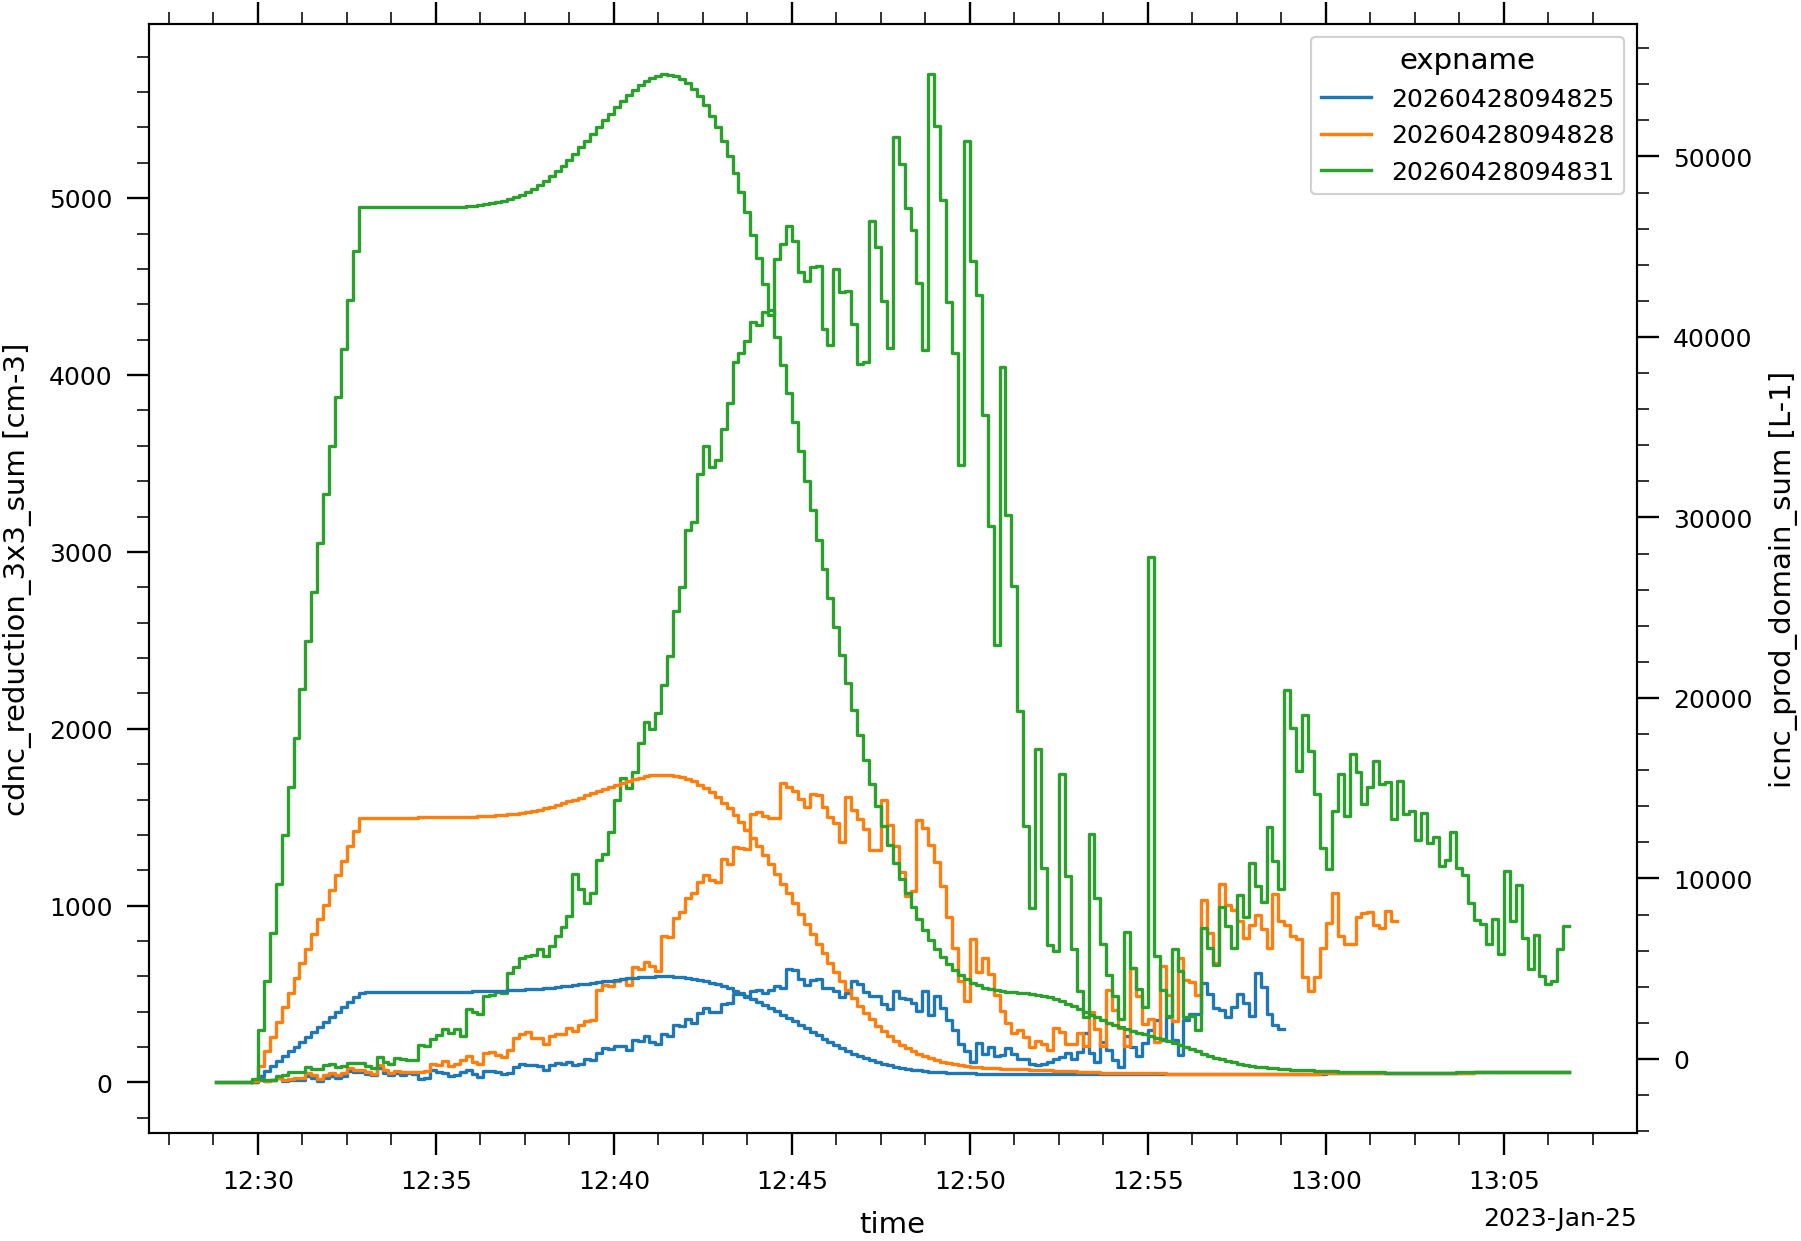

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt


def _plot_cdnc_by_track(ds, ax, label_prefix: str) -> None:
    da = ds["cdnc_reduction_3x3_sum"]
    if "track_var" in da.dims:
        for trackvar in ds["track_var"].values:
            da.sel(track_var=trackvar).plot.step(
                x="time", ax=ax, label=f"{label_prefix}-{trackvar}"
            )
    else:
        da.plot.step(x="time", ax=ax, label=label_prefix)


fig, ax = plt.subplots()
axr = ax.twinx()

_plot_cdnc_by_track(stats_400m, ax, "400m")
_plot_cdnc_by_track(stats_100m, ax, "100m")

stats_400m["icnc_prod_domain_sum"].plot.step(x="time", ax=axr, label="400m icnc")
stats_100m["icnc_prod_domain_sum"].plot.step(x="time", ax=axr, label="100m icnc")
plt.show()

NameError: name 'movie' is not defined